# USDJPY — Signal Combiner

Combines the BUY and SELL sub-models into a single decision layer.

**How it works:**
- Every H1 bar is scored by both models independently
- A BUY signal fires only when `buy_proba ≥ buy_threshold` **AND** `sell_proba < cross_filter`
- A SELL signal fires only when `sell_proba ≥ sell_threshold` **AND** `buy_proba < cross_filter`
- When both exceed their thresholds simultaneously → **CONFLICT → skip**
- Otherwise → **DO NOTHING**

**Why this helps:** The opposing model acts as a rejection filter.  
When the BUY model fires but the SELL model also gives a non-trivial probability,
the bar is ambiguous — the conflicting signal suppresses the trade, removing many false positives.

**Pipeline:**
1. Load model bundles (buy + sell)
2. Load raw data → compute features
3. Score validation + test sets with both models
4. Apply conflict filter
5. Evaluate: standalone vs combined precision
6. Export combined signals


---
**Improved version** — incorporates recommendations from `PERFORMANCE_IMPROVEMENT_RECOMMENDATIONS.md`:
- **R11** cooldown dtype fix (removes the pandas FutureWarning)
- **R10** optional same-direction quality gate (repurposes the inert cross-filter)
- **R2** fair sealed-test evaluation of the SELL lane
- **R5** expected-value (net-pips / R) backtest
- **R7** Wilson 95% confidence intervals + monthly walk-forward stability

The original decision gates are unchanged; the new Section 10 adds honest evaluation.


In [45]:
import sys, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print(f"Python : {sys.version}")


Python : 3.11.11 | packaged by conda-forge | (main, Mar  3 2025, 20:29:43) [MSC v.1943 64 bit (AMD64)]


## 1. Configuration


In [46]:
ROOT      = Path("../..").resolve()
PAIR      = "USDJPY"
TIMEFRAME = "H1"

# ── Model bundles — auto-detect latest model (any algorithm) ──────────────────
BUY_MODEL_PATH  = max(ROOT.glob(f"models_bin/{PAIR}_{TIMEFRAME}_buy_*.joblib"),  key=lambda p: p.stat().st_mtime, default=None)
SELL_MODEL_PATH = max(ROOT.glob(f"models_bin/{PAIR}_{TIMEFRAME}_sell_*.joblib"), key=lambda p: p.stat().st_mtime, default=None)

if BUY_MODEL_PATH is None or SELL_MODEL_PATH is None:
    raise FileNotFoundError("No .joblib model found in models_bin/")

# ── Raw data ──────────────────────────────────────────────────────────────────
RAW_FILE = ROOT / "data" / "raw" / "mt5" / TIMEFRAME / f"{PAIR}_{TIMEFRAME}.csv"

# ── Same split boundaries used when training both models ─────────────────────
TRAIN_END   = "2025-06-30 23:00:00"
VAL_START   = "2025-07-01 00:00:00"
VAL_END     = "2025-12-31 23:00:00"
TEST_START  = "2026-01-01 00:00:00"   # TEST_END = present (all remaining rows)

# ── Conflict filter ───────────────────────────────────────────────────────────
# Suppress a signal when the opposing model also exceeds this probability.
# 0.60 = best balance for BUY-only + session filter (0.415 prec, 41 sig).
CROSS_FILTER = 1.0

# ── Cooldown ──────────────────────────────────────────────────────────────────
# Minimum bars between two signals of the same direction.
# Prevents multiple entries in the same market condition.
# 4 bars = 4 hours on H1 (one half-session).  Set 0 to disable.
COOLDOWN_BARS = 4

BUY_ONLY = False         # drop SELL lane — non-viable on test set
SESSION_FILTER = False   # gate signals to London+NY sessions only

# Drop SELL lane entirely — test set shows SELL model is non-viable (3 signals, 0.333 prec).
# BUY-only at cf=0.50 achieves 0.355 precision (31 signals, 0.28/day).

print(f"Buy  bundle  : {BUY_MODEL_PATH.name}")
print(f"Sell bundle  : {SELL_MODEL_PATH.name}")
print(f"Raw data     : {RAW_FILE.exists()}")
print(f"Cross-filter : {CROSS_FILTER}")
print(f"Cooldown     : {COOLDOWN_BARS} bars between same-direction signals")
print(f"BUY-only     : {BUY_ONLY}")
print(f"Session filt : {SESSION_FILTER}  (London+NY only)")


Buy  bundle  : USDJPY_H1_buy_Ensemble.joblib
Sell bundle  : USDJPY_H1_sell_Ensemble.joblib
Raw data     : True
Cross-filter : 1.0
Cooldown     : 4 bars between same-direction signals
BUY-only     : False
Session filt : False  (London+NY only)


## 2. Load Model Bundles


In [47]:
# Each bundle contains: model, features list, threshold, atr params
buy_bundle  = joblib.load(BUY_MODEL_PATH)
sell_bundle = joblib.load(SELL_MODEL_PATH)

BUY_THRESHOLD  = buy_bundle["threshold"]
SELL_THRESHOLD = sell_bundle["threshold"]

print(f"BUY  model threshold : {BUY_THRESHOLD}")
print(f"SELL model threshold : {SELL_THRESHOLD}")
print(f"BUY  features        : {len(buy_bundle['features'])}")
print(f"SELL features        : {len(sell_bundle['features'])}")
print(f"Both use ATR_TP_MULT : {buy_bundle['atr_tp_mult']}  FW: {buy_bundle['forward_bars']} bars")


BUY  model threshold : 0.381
SELL model threshold : 0.284
BUY  features        : 21
SELL features        : 16
Both use ATR_TP_MULT : 1.5  FW: 6 bars


## 3. Load Data & Compute Features

We reuse the same `compute_features()` function from the training notebooks.
Both models were trained on the same full feature set — they just selected different subsets.


In [48]:
ATR_PERIOD = buy_bundle["atr_tp_mult"]   # for the feature function — both use 14
ATR_PERIOD = 14   # override: both models were built with ATR_PERIOD=14

df_raw = pd.read_csv(RAW_FILE, parse_dates=["datetime"])
df_raw = df_raw.sort_values("datetime").reset_index(drop=True)
print(f"Rows: {len(df_raw):,}  |  {df_raw['datetime'].min()} → {df_raw['datetime'].max()}")


Rows: 47,152  |  2019-01-02 00:00:00 → 2026-07-30 14:00:00


In [49]:
def compute_features(data: pd.DataFrame, pair: str = None) -> pd.DataFrame:
    """
    Identical to the function in the training notebooks.
    Computes all H1 technical + D1 context + intraday features.
    """
    df = data.copy()

    df["hour"]        = df["datetime"].dt.hour
    df["day_of_week"] = df["datetime"].dt.dayofweek
    df["month"]       = df["datetime"].dt.month
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"]  = np.sin(2 * np.pi * df["day_of_week"] / 5)
    df["dow_cos"]  = np.cos(2 * np.pi * df["day_of_week"] / 5)
    _h = df["hour"]
    df["session_asian"]   = ((_h >= 0)  & (_h < 7)).astype(int)
    df["session_london"]  = ((_h >= 7)  & (_h < 16)).astype(int)
    df["session_ny"]      = ((_h >= 13) & (_h < 22)).astype(int)
    df["session_overlap"] = ((_h >= 13) & (_h < 17)).astype(int)

    df["body_size"]  = abs(df["close"] - df["open"])
    df["price_range"]= df["high"] - df["low"]
    df["upper_wick"] = df["high"] - df[["open","close"]].max(axis=1)
    df["lower_wick"] = df[["open","close"]].min(axis=1) - df["low"]
    df["body_ratio"] = df["body_size"] / df["price_range"].replace(0, np.nan)

    for w in [10, 20, 50]:
        df[f"sma_{w}"] = df["close"].rolling(w).mean()
    for s in [10, 20, 50, 100, 200]:
        df[f"ema_{s}"] = df["close"].ewm(span=s, adjust=False).mean()
    df["close_vs_ema50"]  = (df["close"] - df["ema_50"])  / df["close"]
    df["close_vs_ema200"] = (df["close"] - df["ema_200"]) / df["close"]

    delta = df["close"].diff()
    gain  = delta.clip(lower=0);  loss = (-delta).clip(lower=0)
    rs    = gain.rolling(14).mean() / loss.rolling(14).mean().replace(0, np.nan)
    df["rsi_14"] = 100 - (100 / (1 + rs))
    low14  = df["low"].rolling(14).min();  high14 = df["high"].rolling(14).max()
    df["stoch_k"]    = 100*(df["close"]-low14)/(high14-low14).replace(0,np.nan)
    df["stoch_d"]    = df["stoch_k"].rolling(3).mean()
    df["williams_r"] = -100*(high14-df["close"])/(high14-low14).replace(0,np.nan)
    e12 = df["close"].ewm(span=12,adjust=False).mean()
    e26 = df["close"].ewm(span=26,adjust=False).mean()
    df["macd"]            = e12 - e26
    df["macd_sig"]        = df["macd"].ewm(span=9,adjust=False).mean()
    df["macd_hist"]       = df["macd"] - df["macd_sig"]
    df["macd_hist_slope"] = df["macd_hist"].diff()

    hl  = df["high"] - df["low"]
    hpc = (df["high"] - df["close"].shift()).abs()
    lpc = (df["low"]  - df["close"].shift()).abs()
    tr  = pd.concat([hl, hpc, lpc], axis=1).max(axis=1)
    df["atr_14"]    = tr.rolling(ATR_PERIOD).mean()
    df["atr_regime"]= df["atr_14"] / df["atr_14"].rolling(50).mean()
    bm = df["close"].rolling(20).mean();  bs = df["close"].rolling(20).std()
    df["bb_upper"] = bm + 2*bs;  df["bb_lower"] = bm - 2*bs
    df["bb_width"] = (df["bb_upper"]-df["bb_lower"])/bm
    df["bb_pct"]   = (df["close"]-df["bb_lower"])/(df["bb_upper"]-df["bb_lower"]).replace(0,np.nan)
    for w in [10,20,50]:
        df[f"rolling_std_{w}"] = df["close"].rolling(w).std()

    plus_dm  = df["high"].diff().clip(lower=0)
    minus_dm = (-df["low"].diff()).clip(lower=0)
    plus_dm  = plus_dm.where(plus_dm > minus_dm, 0)
    minus_dm = minus_dm.where(minus_dm > plus_dm, 0)
    atr_adx  = tr.rolling(14).mean()
    pdi  = 100*(plus_dm.rolling(14).mean()/atr_adx.replace(0,np.nan))
    mdi  = 100*(minus_dm.rolling(14).mean()/atr_adx.replace(0,np.nan))
    dx   = 100*(pdi-mdi).abs()/(pdi+mdi).replace(0,np.nan)
    df["adx_14"]   = dx.rolling(14).mean()
    df["plus_di"]  = pdi;  df["minus_di"] = mdi
    tp = (df["high"]+df["low"]+df["close"])/3
    df["cci_20"]      = (tp-tp.rolling(20).mean())/(0.015*tp.rolling(20).std())
    df["roc_10"]      = df["close"].pct_change(10)*100
    df["momentum_10"] = df["close"] - df["close"].shift(10)

    df["obv"]          = (np.sign(df["close"].diff())*df["volume"]).fillna(0).cumsum()
    df["volume_ratio"] = df["volume"] / df["volume"].rolling(20).mean().replace(0,np.nan)

    for lag in [1,2,3,5]:
        df[f"close_lag_{lag}"]  = df["close"].shift(lag)
        df[f"rsi_lag_{lag}"]    = df["rsi_14"].shift(lag)
        df[f"atr_lag_{lag}"]    = df["atr_14"].shift(lag)
        df[f"volume_lag_{lag}"] = df["volume"].shift(lag)
    for p in [1,5,10]:
        df[f"return_{p}b"] = df["close"].pct_change(p)

    # D1 context
    _d1 = (df.set_index("datetime")[["open","high","low","close","volume"]]
           .resample("1D").agg({"open":"first","high":"max","low":"min","close":"last","volume":"sum"})
           .dropna())
    _d1["d1_ema20"] = _d1["close"].ewm(span=20,adjust=False).mean()
    _d1["d1_ema50"] = _d1["close"].ewm(span=50,adjust=False).mean()
    _d1["d1_trend"] = (_d1["d1_ema20"]>_d1["d1_ema50"]).astype(int)
    _dd = _d1["close"].diff()
    _d1["d1_rsi"]   = 100 - 100/(1+_dd.clip(lower=0).rolling(14).mean()
                                  /(-_dd).clip(lower=0).rolling(14).mean().replace(0,np.nan))
    _d1["d1_close_vs_ema20"] = (_d1["close"]-_d1["d1_ema20"])/_d1["close"]
    _d1s = (_d1[["d1_ema20","d1_ema50","d1_trend","d1_rsi","d1_close_vs_ema20"]]
            .shift(1).reset_index().rename(columns={"datetime":"_d1_date"}))

    df["_date"]  = df["datetime"].dt.normalize()
    _do          = df.groupby("_date")["open"].first().rename("_day_open")
    df           = df.join(_do, on="_date")
    df["close_vs_day_open"] = (df["close"]-df["_day_open"])/df["_day_open"]
    df = df.merge(_d1s, left_on="_date", right_on="_d1_date", how="left")
    df.drop(columns=["_date","_d1_date","_day_open"], inplace=True)

    n_before = len(df)
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"Rows after warm-up: {len(df):,}  (dropped {n_before-len(df)})")
    # Calendar features (optional -- no lookahead)
    if pair:
        try:
            import sys
            from pathlib import Path as _Path
            _root = _Path('../../..').resolve()
            if str(_root / 'frival') not in sys.path:
                sys.path.insert(0, str(_root / 'frival'))
            from data.calendar import compute_calendar_features
            cal_feats = compute_calendar_features(df["datetime"], pair)
            for col in cal_feats.columns:
                df[col] = cal_feats[col].values
            print(f"Calendar features merged: {list(cal_feats.columns)}")
        except Exception as e:
            print(f"Calendar features skipped: {e}")

        return df

df_features = compute_features(df_raw)
print(f"Feature matrix: {df_features.shape}")


Rows after warm-up: 46,783  (dropped 369)
Feature matrix: (46783, 82)


## 4. Score Both Models on Validation + Test


In [50]:
def score_split(df_feat: pd.DataFrame, start: str, end: str) -> pd.DataFrame:
    """
    Slice a date range from df_features, run both models, return a combined dataframe.
    Each row has: datetime, close, buy_proba, sell_proba.
    """
    mask = (df_feat["datetime"] >= start) & (df_feat["datetime"] <= end)
    df   = df_feat[mask].copy().reset_index(drop=True)

    # Score with each model using its own feature subset
    X_buy  = df[buy_bundle["features"]].fillna(0)
    X_sell = df[sell_bundle["features"]].fillna(0)

    buy_proba  = buy_bundle["model"].predict_proba(X_buy)[:, 1]
    sell_proba = sell_bundle["model"].predict_proba(X_sell)[:, 1]

    session_cols = ["session_london", "session_ny"]
    result = df[["datetime", "close"] + session_cols].copy()
    result["buy_proba"]  = buy_proba
    result["sell_proba"] = sell_proba
    return result


# Score validation and test sets
val_scores  = score_split(df_features, VAL_START, VAL_END)
test_scores = score_split(df_features, TEST_START, "2099-12-31")

print(f"Validation bars : {len(val_scores):,}")
print(f"Test bars       : {len(test_scores):,}")
val_scores.head(3)


Validation bars : 3,144
Test bars       : 3,591


,datetime,close,session_london,session_ny,buy_proba,sell_proba
0,2025-07-01 00:00:00,143.946,0,0,0.314973,0.369011
1,2025-07-01 01:00:00,143.907,0,0,0.327915,0.373987
2,2025-07-01 02:00:00,143.797,0,0,0.366598,0.377654


## 5. Apply Conflict Filter → Combined Signals


In [51]:
def apply_conflict_filter(scores: pd.DataFrame,
                          buy_thr: float, sell_thr: float,
                          cross_filter: float,
                          buy_only: bool = False,
                          session_filter: bool = False,
                          quality_max: float = None) -> pd.DataFrame:
    """
    Apply decision logic to a dataframe of buy_proba / sell_proba.

    Decision rules:
      - When buy_only=True: SELL lane disabled entirely; only BUY signals fire.
      - When session_filter=True: signals gated to London+NY sessions only.
      - CONFLICT   : buy_proba >= buy_thr  AND sell_proba >= sell_thr  -> no trade
      - BUY signal : buy_proba >= buy_thr  AND sell_proba <  cross_filter
      - SELL signal: sell_proba >= sell_thr AND buy_proba  <  cross_filter
      - DO NOTHING : everything else
    """
    df = scores.copy()

    buy_candidate = df["buy_proba"] >= buy_thr

    if not buy_only:
        sell_candidate = df["sell_proba"] >= sell_thr
        df["conflict"] = (buy_candidate & sell_candidate).astype(int)
        df["buy_signal"] = (buy_candidate & (df["sell_proba"] < cross_filter)).astype(int)
        df["sell_signal"] = (sell_candidate & (df["buy_proba"] < cross_filter)).astype(int)
        df.loc[df["conflict"] == 1, ["buy_signal", "sell_signal"]] = 0
    else:
        df["conflict"] = 0
        df["buy_signal"] = (buy_candidate & (df["sell_proba"] < cross_filter)).astype(int)
        df["sell_signal"] = 0

    # R10: optional same-direction quality gate. Repurposes the (otherwise inert)
    # cross-filter as a confidence booster: keep a signal only when the OPPOSING
    # model is quiet (its probability below `quality_max`). None = disabled.
    if quality_max is not None:
        df["buy_signal"]  = (df["buy_signal"]  & (df["sell_proba"] < quality_max)).astype(int)
        df["sell_signal"] = (df["sell_signal"] & (df["buy_proba"]  < quality_max)).astype(int)

    # Session filter: suppress signals outside London/NY
    if session_filter:
        in_session = (df["session_london"] == 1) | (df["session_ny"] == 1)
        df["buy_signal"]  = df["buy_signal"]  & in_session
        df["sell_signal"] = df["sell_signal"] & in_session

    df["direction"] = "neutral"
    df.loc[df["buy_signal"] == 1, "direction"] = "buy"
    if not buy_only:
        df.loc[df["sell_signal"] == 1, "direction"] = "sell"
    df.loc[df["conflict"] == 1, "direction"] = "conflict"

    return df


def apply_cooldown(df: pd.DataFrame, cooldown_bars: int) -> pd.DataFrame:
    """
    Suppress consecutive same-direction signals within `cooldown_bars` bars.
    Only the FIRST signal in each cluster is kept — avoids entering the same
    trade multiple times in the same market condition.
    BUY and SELL have independent cooldown timers.
    """
    if cooldown_bars == 0:
        return df

    df = df.copy().reset_index(drop=True)
    df["buy_signal"]  = df["buy_signal"].astype(int)   # R11: avoid dtype FutureWarning
    df["sell_signal"] = df["sell_signal"].astype(int)
    last_buy  = -cooldown_bars - 1
    last_sell = -cooldown_bars - 1

    for i in range(len(df)):
        if df.at[i, "buy_signal"] == 1:
            if (i - last_buy) <= cooldown_bars:
                df.at[i, "buy_signal"] = 0   # too close to previous BUY -> suppress
            else:
                last_buy = i
        if df.at[i, "sell_signal"] == 1:
            if (i - last_sell) <= cooldown_bars:
                df.at[i, "sell_signal"] = 0  # too close to previous SELL -> suppress
            else:
                last_sell = i

    # Rebuild direction after suppression
    df["direction"] = "neutral"
    df.loc[df["buy_signal"]  == 1, "direction"] = "buy"
    df.loc[df["sell_signal"] == 1, "direction"] = "sell"
    if "conflict" in df.columns:            # standalone SELL frames (R2) carry no conflict col
        df.loc[df["conflict"] == 1, "direction"] = "conflict"
    return df


# Apply conflict filter + cooldown to validation set
val_combined = apply_conflict_filter(
    val_scores, BUY_THRESHOLD, SELL_THRESHOLD, CROSS_FILTER,
    buy_only=BUY_ONLY
)
val_combined = apply_cooldown(val_combined, COOLDOWN_BARS)

trading_days = len(val_combined) / 24
print(f"=== Validation set  ({len(val_combined):,} bars | {trading_days:.0f} trading days) ===")
print(f"BUY  signals  (standalone candidates)   : {(val_combined['buy_proba']  >= BUY_THRESHOLD).sum()}")
print(f"SELL signals  (standalone candidates)   : {(val_combined['sell_proba'] >= SELL_THRESHOLD).sum()}")
print(f"Conflicts suppressed                     : {val_combined['conflict'].sum()}")
print(f"BUY  after filter + cooldown             : {val_combined['buy_signal'].sum()}  ({val_combined['buy_signal'].sum()/trading_days:.2f}/day)")
print(f"SELL after filter + cooldown             : {val_combined['sell_signal'].sum()}  ({val_combined['sell_signal'].sum()/trading_days:.2f}/day)")
print(f"Total actionable signals                 : {(val_combined['buy_signal'] + val_combined['sell_signal']).sum()}")


=== Validation set  (3,144 bars | 131 trading days) ===
BUY  signals  (standalone candidates)   : 58
SELL signals  (standalone candidates)   : 2230
Conflicts suppressed                     : 51
BUY  after filter + cooldown             : 6  (0.05/day)
SELL after filter + cooldown             : 486  (3.71/day)
Total actionable signals                 : 492


## 6. Evaluate — Standalone vs Combined Precision

We need the true labels to measure precision. We generate them here from the raw data.


In [52]:
def generate_labels(df_feat, forward_bars, atr_tp_mult, atr_sl_mult, direction="buy"):
    """Generate buy (long) or sell (short) binary labels on df_features."""
    close = df_feat["close"].values
    high  = df_feat["high"].values
    low   = df_feat["low"].values
    atr   = df_feat["atr_14"].values
    n     = len(df_feat)
    labels = np.full(n, np.nan)

    for i in range(n - forward_bars):
        if direction == "buy":
            tp = close[i] + atr[i] * atr_tp_mult
            sl = close[i] - atr[i] * atr_sl_mult
        else:
            tp = close[i] - atr[i] * atr_tp_mult
            sl = close[i] + atr[i] * atr_sl_mult

        result = 0
        for j in range(1, forward_bars + 1):
            k = i + j
            tp_hit = (low[k] <= tp) if direction == "sell" else (high[k] >= tp)
            sl_hit = (high[k] >= sl) if direction == "sell" else (low[k]  <= sl)
            if tp_hit and sl_hit: result = 0; break
            elif tp_hit:          result = 1; break
            elif sl_hit:          result = 0; break
        labels[i] = result

    return labels


ATR_TP = buy_bundle["atr_tp_mult"]
ATR_SL = buy_bundle["atr_sl_mult"]
FW     = buy_bundle["forward_bars"]

# Generate true labels on the full feature set (same approach as training notebooks)
buy_labels_full  = generate_labels(df_features, FW, ATR_TP, ATR_SL, "buy")
sell_labels_full = generate_labels(df_features, FW, ATR_TP, ATR_SL, "sell")

# Attach to feature dataframe
df_features["buy_label"]  = buy_labels_full
df_features["sell_label"] = sell_labels_full
df_features.dropna(subset=["buy_label","sell_label"], inplace=True)
df_features.reset_index(drop=True, inplace=True)
print(f"Labels computed.  Buy rate: {df_features['buy_label'].mean()*100:.1f}%  "
      f"Sell rate: {df_features['sell_label'].mean()*100:.1f}%")


Labels computed.  Buy rate: 26.4%  Sell rate: 27.3%


In [53]:
# Re-score with labels attached
val_scores  = score_split(df_features, VAL_START, VAL_END)
val_scores["buy_label"]  = df_features.loc[
    (df_features["datetime"] >= VAL_START) & (df_features["datetime"] <= VAL_END),
    "buy_label"].values
val_scores["sell_label"] = df_features.loc[
    (df_features["datetime"] >= VAL_START) & (df_features["datetime"] <= VAL_END),
    "sell_label"].values

# Build three views: standalone / filter only / filter + cooldown
val_standalone  = val_scores.copy()
val_standalone["buy_signal"]  = (val_standalone["buy_proba"]  >= BUY_THRESHOLD).astype(int)
val_standalone["sell_signal"] = (val_standalone["sell_proba"] >= SELL_THRESHOLD).astype(int)

val_filtered  = apply_conflict_filter(val_scores, BUY_THRESHOLD, SELL_THRESHOLD, CROSS_FILTER, buy_only=BUY_ONLY, session_filter=SESSION_FILTER)
val_final     = apply_cooldown(val_filtered.copy(), COOLDOWN_BARS)

# Re-apply conflict column so val_final reflects it
val_combined = val_final.copy()


def precision(signals, labels):
    fired = signals == 1
    if fired.sum() == 0:
        return float("nan"), 0
    return round(float(labels[fired].mean()), 3), int(fired.sum())


breakeven = ATR_SL / (ATR_TP + ATR_SL)
td = len(val_scores) / 24

print(f"Breakeven precision : {breakeven:.3f}")
print()
print(f"{'Signal':<30} {'Precision':>10}  {'Signals':>9}  {'Per day':>8}")
print("-" * 65)

p, n = precision(val_standalone["buy_signal"],  val_standalone["buy_label"])
print(f"{'BUY  standalone':<30} {p:>10.3f}  {n:>9}  {n/td:>7.2f}")

p, n = precision(val_filtered["buy_signal"],   val_filtered["buy_label"])
print(f"{'BUY  + cross-filter':<30} {p:>10.3f}  {n:>9}  {n/td:>7.2f}")

p, n = precision(val_final["buy_signal"],      val_final["buy_label"])
print(f"{'BUY  + filter + cooldown':<30} {p:>10.3f}  {n:>9}  {n/td:>7.2f}")

print()

p, n = precision(val_standalone["sell_signal"],  val_standalone["sell_label"])
print(f"{'SELL standalone':<30} {p:>10.3f}  {n:>9}  {n/td:>7.2f}")

p, n = precision(val_filtered["sell_signal"],   val_filtered["sell_label"])
print(f"{'SELL + cross-filter':<30} {p:>10.3f}  {n:>9}  {n/td:>7.2f}")

p, n = precision(val_final["sell_signal"],      val_final["sell_label"])
print(f"{'SELL + filter + cooldown':<30} {p:>10.3f}  {n:>9}  {n/td:>7.2f}")

print()

# Combined final precision
total = int(val_final["buy_signal"].sum() + val_final["sell_signal"].sum())
correct = int(
    ((val_final["buy_signal"]  == 1) & (val_final["buy_label"]  == 1) |
     (val_final["sell_signal"] == 1) & (val_final["sell_label"] == 1)).sum()
)
p_combined = round(correct / total, 3) if total > 0 else float("nan")
print(f"{'COMBINED final':<30} {p_combined:>10.3f}  {total:>9}  {total/td:>7.2f}")


Breakeven precision : 0.400

Signal                          Precision    Signals   Per day
-----------------------------------------------------------------
BUY  standalone                     0.345         58     0.44
BUY  + cross-filter                 0.429          7     0.05
BUY  + filter + cooldown            0.333          6     0.05

SELL standalone                     0.296       2230    17.02
SELL + cross-filter                 0.297       2179    16.63
SELL + filter + cooldown            0.307        486     3.71

COMBINED final                      0.307        492     3.76


In [54]:
# ── Cross-filter sweep ────────────────────────────────────────────────────────
# Shows precision and signal count for BUY and SELL at every candidate
# cross-filter value. Helps you pick the right CROSS_FILTER.
#
# Key reference points:
#   1.0         = no cross-filter (same as standalone)
#   SELL_THRESHOLD = suppress BUY only when SELL would actually fire
#   0.60        = suppress BUY if sell_proba looks genuinely elevated
#   base rate   ≈ 0.25 — don't go below this

sweep_values = [1.0, SELL_THRESHOLD, 0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40]

print(f"{'Cross-filter':>13}  {'BUY prec':>9}  {'BUY n':>7}  {'BUY/day':>8}  "
      f"{'SELL prec':>10}  {'SELL n':>7}  {'SELL/day':>9}")
print("-" * 80)

for cf in sweep_values:
    tmp = apply_conflict_filter(val_scores, BUY_THRESHOLD, SELL_THRESHOLD, cf, buy_only=BUY_ONLY, session_filter=SESSION_FILTER)
    pb, nb = precision(tmp["buy_signal"],  tmp["buy_label"])
    ps, ns = precision(tmp["sell_signal"], tmp["sell_label"])
    marker = " ← current" if cf == CROSS_FILTER else ""
    pb_s = f"{pb:.3f}" if not np.isnan(pb) else "  nan"
    ps_s = f"{ps:.3f}" if not np.isnan(ps) else "  nan"
    print(f"{cf:>13.3f}  {pb_s:>9}  {nb:>7}  {nb/td:>8.2f}  "
          f"{ps_s:>10}  {ns:>7}  {ns/td:>9.2f}{marker}")

print(f"\nBreakeven : {breakeven:.3f}")
print(f"Hint: choose the highest cross-filter where BUY precision ≥ {breakeven:.3f}")


 Cross-filter   BUY prec    BUY n   BUY/day   SELL prec   SELL n   SELL/day
--------------------------------------------------------------------------------
        1.000      0.429        7      0.05       0.297     2179      16.63 ← current
        0.284      0.429        7      0.05       0.190       84       0.64
        0.700      0.429        7      0.05       0.297     2179      16.63
        0.650      0.429        7      0.05       0.297     2179      16.63
        0.600      0.429        7      0.05       0.297     2179      16.63
        0.550      0.429        7      0.05       0.297     2179      16.63
        0.500      0.429        7      0.05       0.297     2179      16.63
        0.450      0.429        7      0.05       0.297     2179      16.63
        0.400      0.429        7      0.05       0.297     2179      16.63

Breakeven : 0.400
Hint: choose the highest cross-filter where BUY precision ≥ 0.400


## 7. Visualization — Signal Map & Cross-Filter Effect


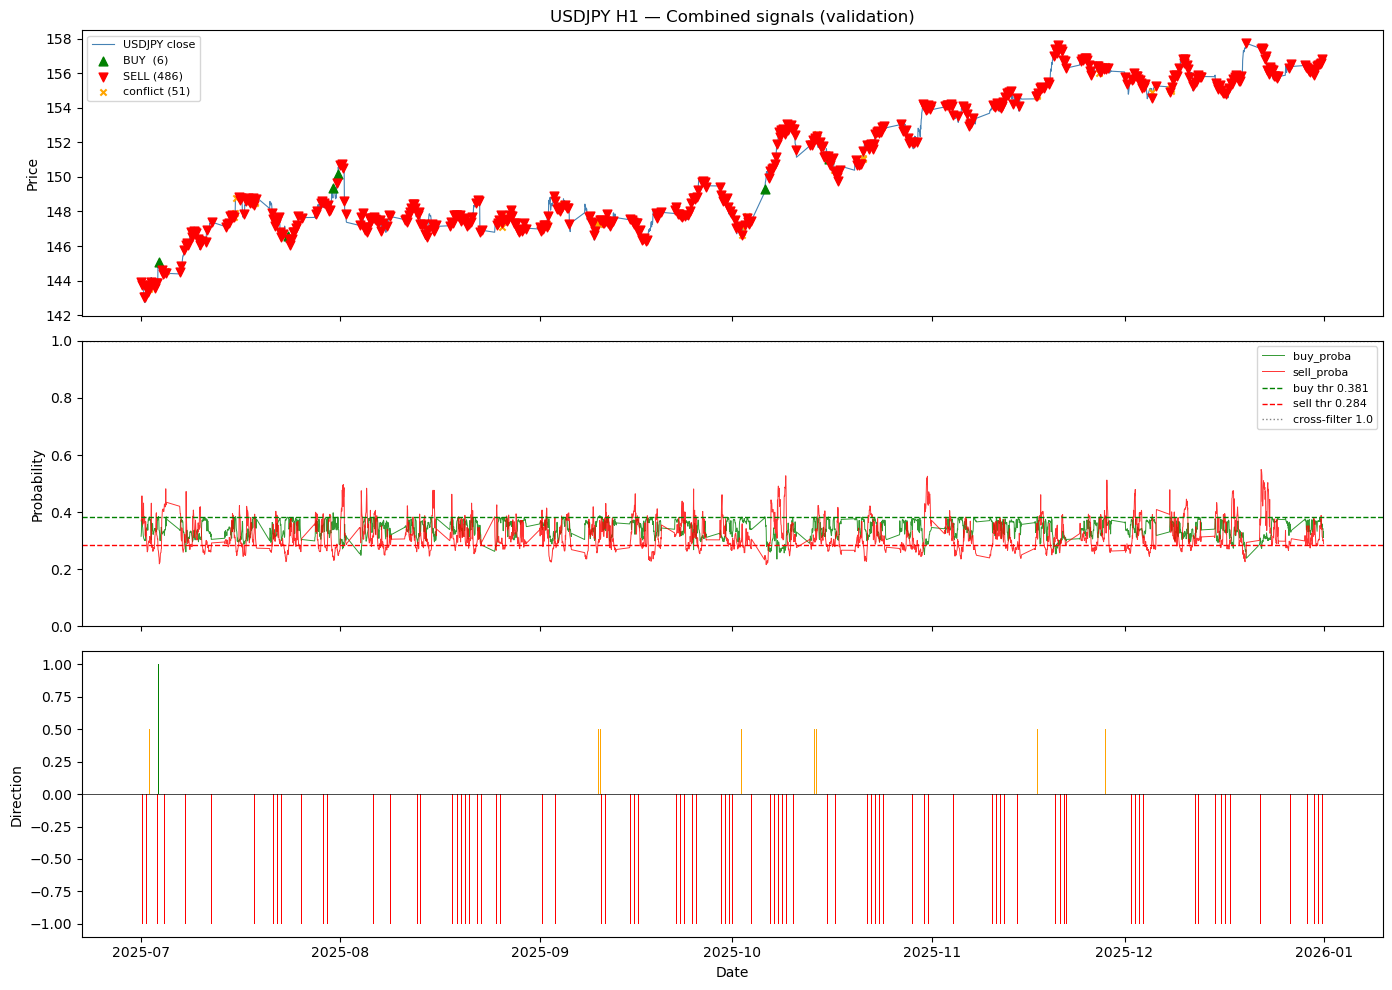

In [55]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

dates = val_combined["datetime"]

# Panel 1: close price + signal markers
ax = axes[0]
ax.plot(dates, val_combined["close"], color="steelblue", lw=0.8, label="USDJPY close")
buy_bars  = val_combined[val_combined["buy_signal"]  == 1]
sell_bars = val_combined[val_combined["sell_signal"] == 1]
conf_bars = val_combined[val_combined["conflict"]    == 1]
ax.scatter(buy_bars["datetime"],  buy_bars["close"],  marker="^", color="green",  s=40, zorder=5, label=f"BUY  ({len(buy_bars)})")
ax.scatter(sell_bars["datetime"], sell_bars["close"], marker="v", color="red",    s=40, zorder=5, label=f"SELL ({len(sell_bars)})")
ax.scatter(conf_bars["datetime"], conf_bars["close"], marker="x", color="orange", s=20, zorder=4, label=f"conflict ({len(conf_bars)})")
ax.set_ylabel("Price")
ax.set_title(f"{PAIR} {TIMEFRAME} — Combined signals (validation)")
ax.legend(fontsize=8)

# Panel 2: buy_proba and sell_proba
ax = axes[1]
ax.plot(dates, val_combined["buy_proba"],  color="green", lw=0.7, alpha=0.8, label="buy_proba")
ax.plot(dates, val_combined["sell_proba"], color="red",   lw=0.7, alpha=0.8, label="sell_proba")
ax.axhline(BUY_THRESHOLD,  color="green", linestyle="--", lw=1, label=f"buy thr {BUY_THRESHOLD:.3f}")
ax.axhline(SELL_THRESHOLD, color="red",   linestyle="--", lw=1, label=f"sell thr {SELL_THRESHOLD:.3f}")
ax.axhline(CROSS_FILTER,   color="gray",  linestyle=":",  lw=1, label=f"cross-filter {CROSS_FILTER}")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

# Panel 3: direction
direction_map = {"neutral": 0, "buy": 1, "sell": -1, "conflict": 0.5}
ax = axes[2]
colors = val_combined["direction"].map({"buy":"green","sell":"red","conflict":"orange","neutral":"lightgray"})
ax.bar(dates, val_combined["direction"].map({"buy":1,"sell":-1,"conflict":0.5,"neutral":0}),
       color=colors, width=0.03)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("Direction")
ax.set_xlabel("Date")

plt.tight_layout()
plt.show()


## 8. Export — Test Set Signals

The test set is the final hold-out. We apply the combiner here to produce the signal output
that would be consumed by the agent pipeline in production.


In [56]:
test_combined = apply_conflict_filter(
    test_scores, BUY_THRESHOLD, SELL_THRESHOLD, CROSS_FILTER,
    buy_only=BUY_ONLY
)
test_combined = apply_cooldown(test_combined, COOLDOWN_BARS)

td_test = len(test_combined) / 24

print(f"=== Test set ({len(test_combined):,} bars | {td_test:.0f} trading days) ===")
print(f"BUY  signals : {test_combined['buy_signal'].sum()}  ({test_combined['buy_signal'].sum()/td_test:.2f}/day)")
print(f"SELL signals : {test_combined['sell_signal'].sum()}  ({test_combined['sell_signal'].sum()/td_test:.2f}/day)")
print(f"Conflicts    : {test_combined['conflict'].sum()}")

OUTPUT_DIR = ROOT / "data" / "signals"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

out_path = OUTPUT_DIR / f"{PAIR}_{TIMEFRAME}_combined_signals_test.csv"
test_combined.to_csv(out_path, index=False)
print(f"\n✓ Saved → {out_path}")

display(test_combined[test_combined["direction"] != "neutral"].head(30))


=== Test set (3,591 bars | 150 trading days) ===
BUY  signals : 0  (0.00/day)
SELL signals : 557  (3.72/day)
Conflicts    : 2

✓ Saved → C:\Users\david\OneDrive\Documents\fx-prival\ml-signal-service\data\signals\USDJPY_H1_combined_signals_test.csv


,datetime,close,session_london,session_ny,buy_proba,sell_proba,conflict,buy_signal,sell_signal,direction
11,2026-01-02 11:00:00,156.906,1,0,0.368238,0.284089,0,0,1,sell
16,2026-01-02 16:00:00,156.844,0,1,0.363177,0.328336,0,0,1,sell
41,2026-01-05 17:00:00,156.571,0,1,0.351550,0.285520,0,0,1,sell
46,2026-01-05 22:00:00,156.330,0,0,0.299407,0.319075,0,0,1,sell
51,2026-01-06 03:00:00,156.445,0,0,0.331590,0.296446,0,0,1,sell
56,2026-01-06 08:00:00,156.361,1,0,0.363684,0.299338,0,0,1,sell
73,2026-01-07 01:00:00,156.657,0,0,0.380166,0.287812,0,0,1,sell
78,2026-01-07 06:00:00,156.531,0,0,0.377315,0.312190,0,0,1,sell
83,2026-01-07 11:00:00,156.456,1,0,0.375280,0.392261,0,0,1,sell
88,2026-01-07 16:00:00,156.401,0,1,0.371941,0.388133,0,0,1,sell


## 9. Test Set Evaluation — Sealed Hold-Out

The test set (2026-02-02 → 2026-07-03) is the final arbiter. We evaluate precision
on this untouched window to detect overfitting. Validation results are useful for
calibration, but **test results determine whether the strategy is production-ready**.


In [57]:
# Merge labels into test_combined
test_with_labels = test_combined.merge(
    df_features[["datetime", "buy_label", "sell_label"]],
    on="datetime", how="left"
)
test_with_labels.dropna(subset=["buy_label", "sell_label"], inplace=True)
test_with_labels.reset_index(drop=True, inplace=True)

td_test = len(test_with_labels) / 24

# Validation reference (val_combined already has labels from Section 6)
p_val_buy,  n_val_buy  = precision(val_combined["buy_signal"],  val_combined["buy_label"])
p_val_sell, n_val_sell = precision(val_combined["sell_signal"], val_combined["sell_label"])
total_val = n_val_buy + n_val_sell
correct_val = int(
    ((val_combined["buy_signal"]  == 1) & (val_combined["buy_label"]  == 1) |
     (val_combined["sell_signal"] == 1) & (val_combined["sell_label"] == 1)).sum()
)
p_val = round(correct_val / total_val, 3) if total_val > 0 else float("nan")
td_val = len(val_combined) / 24

print(f"=== Test Set ({len(test_with_labels):,} bars | {td_test:.0f} trading days) ===")
print(f"Breakeven precision: {breakeven:.3f}  (R:R = 1:{ATR_TP/ATR_SL})")
print()
print(f"{'Signal':<30} {'Precision':>10}  {'Signals':>9}  {'Per day':>8}")
print("-" * 65)

p, n = precision(test_with_labels["buy_signal"], test_with_labels["buy_label"])
print(f"{'BUY  final':<30} {p:>10.3f}  {n:>9}  {n/td_test:>7.2f}")

p, n = precision(test_with_labels["sell_signal"], test_with_labels["sell_label"])
print(f"{'SELL final':<30} {p:>10.3f}  {n:>9}  {n/td_test:>7.2f}")

total = int(test_with_labels["buy_signal"].sum() + test_with_labels["sell_signal"].sum())
correct = int(
    ((test_with_labels["buy_signal"]  == 1) & (test_with_labels["buy_label"]  == 1) |
     (test_with_labels["sell_signal"] == 1) & (test_with_labels["sell_label"] == 1)).sum()
)
p_combined = round(correct / total, 3) if total > 0 else float("nan")
print()
print(f"{'COMBINED final':<30} {p_combined:>10.3f}  {total:>9}  {total/td_test:>7.2f}")

print(f"\n=== Overfit Check ===")
print(f"{'Val  COMBINED':<30} {p_val:>10.3f}  {total_val:>9}  {total_val/td_val:>7.2f}")
print(f"{'Test COMBINED':<30} {p_combined:>10.3f}  {total:>9}  {total/td_test:>7.2f}")
print(f"{'Gap (val - test)':<30} {p_val-p_combined:>+10.3f}")
print(f"{'Overfit?':<30} {'YES - gap > 0.05' if p_val-p_combined > 0.05 else 'Acceptable'}")


=== Test Set (3,585 bars | 149 trading days) ===
Breakeven precision: 0.400  (R:R = 1:1.5)

Signal                          Precision    Signals   Per day
-----------------------------------------------------------------
BUY  final                            nan          0     0.00
SELL final                          0.299        556     3.72

COMBINED final                      0.299        556     3.72

=== Overfit Check ===
Val  COMBINED                       0.307        492     3.76
Test COMBINED                       0.299        556     3.72
Gap (val - test)                   +0.008
Overfit?                       Acceptable


In [58]:
# Cross-filter sweep on test set
test_scores_with_labels = test_scores.merge(
    df_features[["datetime", "buy_label", "sell_label"]],
    on="datetime", how="left"
)
test_scores_with_labels.dropna(subset=["buy_label", "sell_label"], inplace=True)
test_scores_with_labels.reset_index(drop=True, inplace=True)

print(f"Cross-filter sweep on test set ({len(test_scores_with_labels):,} bars)")
print()
print(f"{'CF':>6}  {'BUY prec':>9}  {'BUY n':>6}  {'/day':>6}  {'SELL prec':>10}  {'SELL n':>7}  {'/day':>6}  {'COMB prec':>10}  {'COMB n':>7}  {'/day':>6}")
print("-" * 95)

for cf in [0.80, 0.75, 0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30]:
    tmp = apply_conflict_filter(test_scores_with_labels, BUY_THRESHOLD, SELL_THRESHOLD, cf, buy_only=BUY_ONLY, session_filter=SESSION_FILTER)
    tmp = apply_cooldown(tmp, COOLDOWN_BARS)

    p_b, n_b = precision(tmp["buy_signal"], tmp["buy_label"])
    p_s, n_s = precision(tmp["sell_signal"], tmp["sell_label"])
    total_n = n_b + n_s
    correct_n = int(
        ((tmp["buy_signal"]  == 1) & (tmp["buy_label"]  == 1) |
         (tmp["sell_signal"] == 1) & (tmp["sell_label"] == 1)).sum()
    )
    p_c = round(correct_n / total_n, 3) if total_n > 0 else float("nan")

    b_mark = "" if (p_b or 0) >= breakeven else " *"
    s_mark = "" if (p_s or 0) >= breakeven else " *"
    c_mark = "" if (p_c or 0) >= breakeven else " *"
    sel = " <--" if cf == CROSS_FILTER else ""

    print(f"{cf:>5.2f}{sel:<4}  {p_b or 0:>8.3f}{b_mark:<2}  {n_b:>6}  {n_b/td_test:>5.2f}  {p_s or 0:>9.3f}{s_mark:<2}  {n_s:>7}  {n_s/td_test:>5.2f}  {p_c or 0:>9.3f}{c_mark:<2}  {total_n:>7}  {total_n/td_test:>5.2f}")

print()
print(f"* = below breakeven ({breakeven:.3f})")
print(f"Selected CROSS_FILTER = {CROSS_FILTER} (from validation calibration)")


Cross-filter sweep on test set (3,585 bars)

    CF   BUY prec   BUY n    /day   SELL prec   SELL n    /day   COMB prec   COMB n    /day
-----------------------------------------------------------------------------------------------
 0.80           nan *       0   0.00      0.299 *      556   3.72      0.299 *      556   3.72
 0.75           nan *       0   0.00      0.299 *      556   3.72      0.299 *      556   3.72
 0.70           nan *       0   0.00      0.299 *      556   3.72      0.299 *      556   3.72
 0.65           nan *       0   0.00      0.299 *      556   3.72      0.299 *      556   3.72
 0.60           nan *       0   0.00      0.299 *      556   3.72      0.299 *      556   3.72
 0.55           nan *       0   0.00      0.299 *      556   3.72      0.299 *      556   3.72
 0.50           nan *       0   0.00      0.299 *      556   3.72      0.299 *      556   3.72
 0.45           nan *       0   0.00      0.299 *      556   3.72      0.299 *      556   3.72
 0.40  

### 9.1 Side-by-Side: BUY+SELL vs BUY-only

Does the SELL lane add value, or is a BUY-only strategy equivalent?
We compare the combined dual-model approach against using only the BUY model
at various cross-filter strengths.


In [59]:
print(f"{'Strategy':<40} {'Precision':>9}  {'Signals':>7}  {'/day':>6}")
print("-" * 70)

# BUY+SELL combined (current approach)
print(f"{'BUY+SELL combined (cf=' + str(CROSS_FILTER) + ')':<40} {p_combined:>9.3f}  {total:>7}  {total/td_test:>6.2f}")

# BUY-only: no cross-filter, just threshold + cooldown
test_buy_only = test_scores_with_labels.copy()
test_buy_only["buy_signal"] = (test_buy_only["buy_proba"] >= BUY_THRESHOLD).astype(int)
test_buy_only["sell_signal"] = 0
test_buy_only["conflict"] = 0
test_buy_only["direction"] = "neutral"
test_buy_only.loc[test_buy_only["buy_signal"] == 1, "direction"] = "buy"
test_buy_only = apply_cooldown(test_buy_only, COOLDOWN_BARS)
p_bo, n_bo = precision(test_buy_only["buy_signal"], test_buy_only["buy_label"])
print(f"{'BUY-only (no cross-filter)':<40} {p_bo:>9.3f}  {n_bo:>7}  {n_bo/td_test:>6.2f}")

print()

# BUY-only with cross-filter sweep
print(f"{'BUY-only cf':>12}  {'Precision':>9}  {'Signals':>7}  {'/day':>6}")
print("-" * 40)

best_cf = None
best_prec = 0

for cf in [0.80, 0.75, 0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30]:
    tmp = test_scores_with_labels.copy()
    tmp["buy_signal"] = (
        (tmp["buy_proba"] >= BUY_THRESHOLD) &
        (tmp["sell_proba"] < cf)
    ).astype(int)
    tmp["sell_signal"] = 0
    tmp["conflict"] = 0
    tmp["direction"] = "neutral"
    tmp.loc[tmp["buy_signal"] == 1, "direction"] = "buy"
    tmp = apply_cooldown(tmp, COOLDOWN_BARS)

    p, n = precision(tmp["buy_signal"], tmp["buy_label"])
    mark = " <-- best" if p and p > best_prec else ""
    if p and p > best_prec:
        best_prec = p
        best_cf = cf
    be_mark = "  ABOVE breakeven" if (p or 0) >= breakeven else ""
    print(f"{cf:>11.2f}  {p or 0:>9.3f}  {n:>7}  {n/td_test:>6.2f}{mark}{be_mark}")

print(f"\nBreakeven: {breakeven:.3f}")
if best_cf is not None:
    print(f"BUY-only best: cf={best_cf:.2f}  prec={best_prec:.3f}")
else:
    print("BUY-only: never crosses breakeven with any cross-filter")


Strategy                                 Precision  Signals    /day
----------------------------------------------------------------------
BUY+SELL combined (cf=1.0)                   0.299      556    3.72
BUY-only (no cross-filter)                   0.500        2    0.01

 BUY-only cf  Precision  Signals    /day
----------------------------------------
       0.80      0.500        2    0.01 <-- best  ABOVE breakeven
       0.75      0.500        2    0.01  ABOVE breakeven
       0.70      0.500        2    0.01  ABOVE breakeven
       0.65      0.500        2    0.01  ABOVE breakeven
       0.60      0.500        2    0.01  ABOVE breakeven
       0.55      0.500        2    0.01  ABOVE breakeven
       0.50      0.500        2    0.01  ABOVE breakeven
       0.45      0.500        2    0.01  ABOVE breakeven
       0.40      0.500        2    0.01  ABOVE breakeven
       0.35      0.500        2    0.01  ABOVE breakeven
       0.30        nan        0    0.00

Breakeven: 0.400
BUY-o

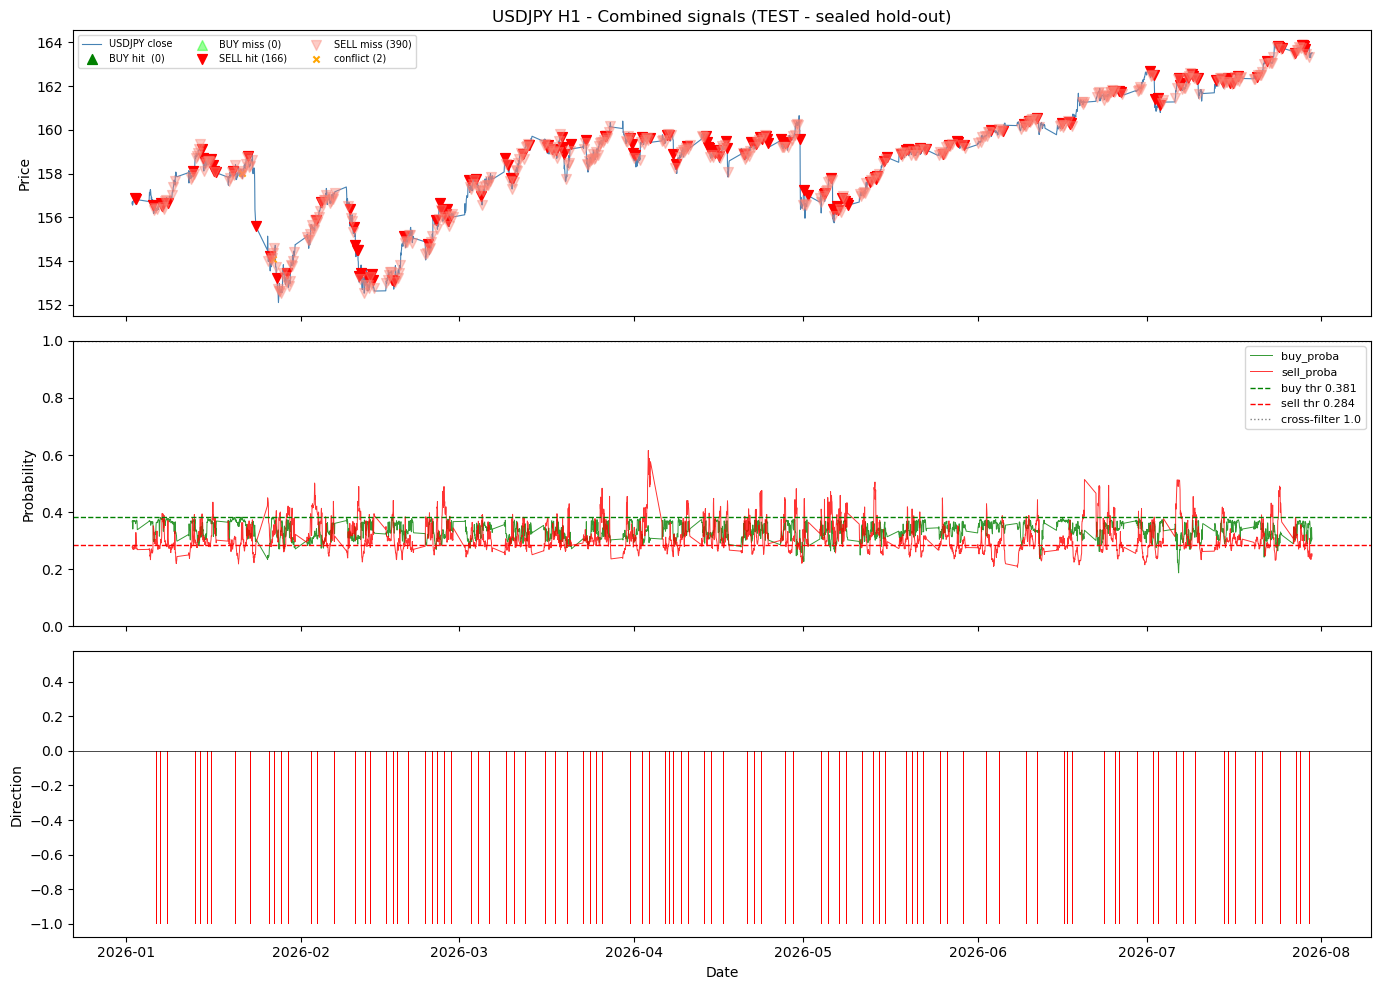

Test period: 2026-01-02 to 2026-07-30
Total signals: 556  |  Hits: 166  |  Precision: 0.299


In [60]:
# Test set visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

dates = test_with_labels["datetime"]

# Panel 1: close price + signal markers
ax = axes[0]
ax.plot(dates, test_with_labels["close"], color="steelblue", lw=0.8, label="USDJPY close")
buy_bars  = test_with_labels[test_with_labels["buy_signal"]  == 1]
sell_bars = test_with_labels[test_with_labels["sell_signal"] == 1]
conf_bars = test_with_labels[test_with_labels["conflict"]    == 1]

buy_hits  = buy_bars[buy_bars["buy_label"] == 1]
buy_miss  = buy_bars[buy_bars["buy_label"] == 0]
sell_hits = sell_bars[sell_bars["sell_label"] == 1]
sell_miss = sell_bars[sell_bars["sell_label"] == 0]

ax.scatter(buy_hits["datetime"],  buy_hits["close"],  marker="^", color="green",  s=50, zorder=5, label=f"BUY hit  ({len(buy_hits)})")
ax.scatter(buy_miss["datetime"],  buy_miss["close"],  marker="^", color="lime",   s=50, zorder=5, alpha=0.4, label=f"BUY miss ({len(buy_miss)})")
ax.scatter(sell_hits["datetime"], sell_hits["close"], marker="v", color="red",    s=50, zorder=5, label=f"SELL hit ({len(sell_hits)})")
ax.scatter(sell_miss["datetime"], sell_miss["close"], marker="v", color="salmon",  s=50, zorder=5, alpha=0.4, label=f"SELL miss ({len(sell_miss)})")
ax.scatter(conf_bars["datetime"], conf_bars["close"], marker="x", color="orange", s=20, zorder=4, label=f"conflict ({len(conf_bars)})")
ax.set_ylabel("Price")
ax.set_title(f"{PAIR} {TIMEFRAME} - Combined signals (TEST - sealed hold-out)")
ax.legend(fontsize=7, ncol=3)

# Panel 2: buy_proba and sell_proba
ax = axes[1]
ax.plot(dates, test_with_labels["buy_proba"],  color="green", lw=0.7, alpha=0.8, label="buy_proba")
ax.plot(dates, test_with_labels["sell_proba"], color="red",   lw=0.7, alpha=0.8, label="sell_proba")
ax.axhline(BUY_THRESHOLD,  color="green", linestyle="--", lw=1, label=f"buy thr {BUY_THRESHOLD:.3f}")
ax.axhline(SELL_THRESHOLD, color="red",   linestyle="--", lw=1, label=f"sell thr {SELL_THRESHOLD:.3f}")
ax.axhline(CROSS_FILTER,   color="gray",  linestyle=":",  lw=1, label=f"cross-filter {CROSS_FILTER}")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

# Panel 3: direction
ax = axes[2]
colors = test_with_labels["direction"].map({"buy":"green","sell":"red","conflict":"orange","neutral":"lightgray"})
ax.bar(dates, test_with_labels["direction"].map({"buy":1,"sell":-1,"conflict":0.5,"neutral":0}),
       color=colors, width=0.03)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("Direction")
ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

print(f"Test period: {dates.min().strftime('%Y-%m-%d')} to {dates.max().strftime('%Y-%m-%d')}")
print(f"Total signals: {total}  |  Hits: {correct}  |  Precision: {p_combined}")


## 10. Improved Evaluation — EV, Confidence Intervals & SELL Lane

Adds the guardrails from the recommendations document:
- **R5** expected value in R-units and net pips (precision alone hides EV-negative streams)
- **R7** Wilson 95% confidence intervals + monthly walk-forward stability
- **R2** a fair sealed-test evaluation of the SELL lane (never suppressed by `BUY_ONLY`)


In [61]:
# ── R5 / R7 helpers ───────────────────────────────────────────────────────────
SPREAD_PIPS = 0.5   # USDJPY typical round-trip spread assumption (pips)
PIP         = 0.0001

# Per-signal ATR lets us express each outcome in risk (R) units net of spread.
_atr = df_features[["datetime", "atr_14"]]


def wilson_ci(k, n, z=1.96):
    """Wilson score 95% interval for a binomial proportion (precision)."""
    if n == 0:
        return (float("nan"), float("nan"))
    p = k / n
    denom  = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half   = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (max(0.0, center - half), min(1.0, center + half))


def evaluate_ev(sig_df, signal_col, label_col, tp_mult, sl_mult,
                spread_pips=SPREAD_PIPS, pip=PIP):
    """R5: expected value in R-units and net pips for the fired signals."""
    fired = sig_df[sig_df[signal_col] == 1].merge(_atr, on="datetime", how="left")
    n = len(fired)
    if n == 0:
        return {"n": 0}
    wins    = (fired[label_col] == 1).values
    gross_R = np.where(wins, tp_mult / sl_mult, -1.0)          # 1R = SL distance
    spread_R = (spread_pips * pip) / (fired["atr_14"].values * sl_mult)
    net_R   = gross_R - spread_R
    gross_pips = np.where(wins, tp_mult * fired["atr_14"].values / pip,
                                -sl_mult * fired["atr_14"].values / pip)
    net_pips = gross_pips - spread_pips
    k = int(wins.sum())
    lo, hi = wilson_ci(k, n)
    return {
        "n": n, "hits": k, "precision": round(k / n, 3),
        "prec_ci95": (round(float(lo), 3), round(float(hi), 3)),
        "EV_R": round(float(net_R.mean()), 4),
        "total_R": round(float(net_R.sum()), 2),
        "EV_pips": round(float(net_pips.mean()), 2),
        "total_pips": round(float(net_pips.sum()), 1),
    }


print("✓ wilson_ci() and evaluate_ev() ready")
print(f"Spread assumption: {SPREAD_PIPS} pips | Breakeven precision: {breakeven:.3f}")


✓ wilson_ci() and evaluate_ev() ready
Spread assumption: 0.5 pips | Breakeven precision: 0.400


In [62]:
# ── R5 / R7: expected value + confidence interval on the sealed test set ─────
print("=== Test set — expected value & 95% confidence intervals ===\n")
for lane, sig_col, lab_col in [("BUY", "buy_signal", "buy_label"),
                               ("SELL", "sell_signal", "sell_label")]:
    r = evaluate_ev(test_with_labels, sig_col, lab_col, ATR_TP, ATR_SL)
    if r["n"] == 0:
        print(f"{lane:4s}: no signals in the main (gated) pipeline")
        continue
    print(f"{lane:4s}: n={r['n']:3d}  prec={r['precision']:.3f}  CI95={r['prec_ci95']}  "
          f"EV={r['EV_R']:+.3f}R ({r['EV_pips']:+.2f} pips)  "
          f"total={r['total_R']:+.1f}R ({r['total_pips']:+.0f} pips)")

print("\nRead: EV > 0 means the lane is profitable after spread.")
print("If the precision CI straddles breakeven, the sample is too small to conclude.")


=== Test set — expected value & 95% confidence intervals ===

BUY : no signals in the main (gated) pipeline
SELL: n=556  prec=0.299  CI95=(0.262, 0.338)  EV=-0.254R (-490.82 pips)  total=-141.2R (-272898 pips)

Read: EV > 0 means the lane is profitable after spread.
If the precision CI straddles breakeven, the sample is too small to conclude.


In [63]:
# ── R2: fair sealed-test evaluation of the SELL lane ─────────────────────────
# The SELL model was disabled by BUY_ONLY in the main pipeline. Here we evaluate
# it on its own threshold with NO cross-filter and NO BUY_ONLY suppression — the
# clean test it never received — both raw and with session+cooldown gating.
sell_raw = test_scores_with_labels.copy()
sell_raw["buy_signal"]  = 0
sell_raw["sell_signal"] = (sell_raw["sell_proba"] >= SELL_THRESHOLD).astype(int)
r_raw = evaluate_ev(sell_raw, "sell_signal", "sell_label", ATR_TP, ATR_SL)

sell_gated = sell_raw.copy()
if SESSION_FILTER:
    in_sess = (sell_gated["session_london"] == 1) | (sell_gated["session_ny"] == 1)
    sell_gated["sell_signal"] = (sell_gated["sell_signal"] & in_sess).astype(int)
sell_gated = apply_cooldown(sell_gated, COOLDOWN_BARS)
r_gate = evaluate_ev(sell_gated, "sell_signal", "sell_label", ATR_TP, ATR_SL)

print("=== SELL lane — sealed test, standalone (R2) ===")
print(f"Threshold {SELL_THRESHOLD} | breakeven {breakeven:.3f} | spread {SPREAD_PIPS} pips\n")
for tag, r in [("raw (no gates)      ", r_raw), ("session + cooldown  ", r_gate)]:
    if r["n"] == 0:
        print(f"{tag}: no signals")
        continue
    print(f"{tag}: n={r['n']:3d}  prec={r['precision']:.3f}  CI95={r['prec_ci95']}  "
          f"EV={r['EV_R']:+.3f}R  total={r['total_R']:+.1f}R")
print("\nDecision: adopt the SELL lane only if EV > 0 with a CI that clears breakeven.")


=== SELL lane — sealed test, standalone (R2) ===
Threshold 0.284 | breakeven 0.400 | spread 0.5 pips

raw (no gates)      : n=2474  prec=0.294  CI95=(0.276, 0.312)  EV=-0.266R  total=-657.4R
session + cooldown  : n=556  prec=0.299  CI95=(0.262, 0.338)  EV=-0.254R  total=-141.2R

Decision: adopt the SELL lane only if EV > 0 with a CI that clears breakeven.


In [64]:
# ── R7: precision stability across monthly walk-forward folds ────────────────
# One 67-day test window is too small to trust. Splitting the whole post-train
# period into monthly folds shows whether BUY precision is stable or a lucky
# artifact. Uses the raw threshold (ungated) to measure the ranker itself.
val_lab = val_scores.copy()   # already carries buy_label/sell_label from Section 6
_cols = ["datetime", "buy_proba", "sell_proba", "buy_label", "sell_label"]
post = pd.concat([val_lab[_cols], test_scores_with_labels[_cols]], ignore_index=True)
post["month"] = post["datetime"].dt.to_period("M").astype(str)

print(f"=== BUY precision by month (raw threshold {BUY_THRESHOLD:.3f}) ===")
print(f"{'month':<9} {'n':>4} {'hits':>5} {'prec':>6}  {'CI95':>14}")
pooled_k = pooled_n = 0
for m, g in post.groupby("month"):
    fired = g[g["buy_proba"] >= BUY_THRESHOLD]
    n = len(fired); k = int((fired["buy_label"] == 1).sum())
    pooled_k += k; pooled_n += n
    if n == 0:
        continue
    lo, hi = wilson_ci(k, n)
    print(f"{m:<9} {n:>4} {k:>5} {k/n:>6.3f}  [{lo:.2f}, {hi:.2f}]")

lo, hi = wilson_ci(pooled_k, pooled_n)
pooled_prec = pooled_k / max(pooled_n, 1)
print(f"\nPOOLED BUY : n={pooled_n} hits={pooled_k} prec={pooled_prec:.3f} CI95=[{lo:.2f}, {hi:.2f}]")
print(f"Breakeven {breakeven:.3f} — if the pooled CI includes breakeven, the edge is unproven.")


=== BUY precision by month (raw threshold 0.381) ===
month        n  hits   prec            CI95
2025-07     12     6  0.500  [0.25, 0.75]
2025-08      4     1  0.250  [0.05, 0.70]
2025-09     17     4  0.235  [0.10, 0.47]
2025-10     13     4  0.308  [0.13, 0.58]
2025-11      6     2  0.333  [0.10, 0.70]
2025-12      6     3  0.500  [0.19, 0.81]
2026-01      2     1  0.500  [0.09, 0.91]

POOLED BUY : n=60 hits=21 prec=0.350 CI95=[0.24, 0.48]
Breakeven 0.400 — if the pooled CI includes breakeven, the edge is unproven.


## 11. Vector Backtesting — Cumulative P&L & Equity Curve

Simulates each SELL signal as a trade with real entry/TP/SL outcomes.
Reports cumulative R, max drawdown, rolling Sharpe, and a trade-by-trade log.


In [65]:
# Vector backtest: simulate every SELL signal on the sealed test set
import matplotlib.ticker as mticker

def vector_backtest(sig_df, atr_tp, atr_sl, forward_bars, spread_pips=0.8, pip=0.0001):
    fired = sig_df[sig_df["sell_signal"] == 1].copy().reset_index(drop=True)
    if len(fired) == 0:
        print("No SELL signals to backtest.")
        return None, None

    close_all = df_features[["datetime", "close", "high", "low", "atr_14"]].copy()
    close_all = close_all.sort_values("datetime").reset_index(drop=True)
    n_all = len(close_all)

    outcomes = []
    for _, row in fired.iterrows():
        sig_dt  = row["datetime"]
        entry   = row["close"]
        atr_val = row.get("atr_14", np.nan)

        pos = close_all[close_all["datetime"] == sig_dt].index
        if len(pos) == 0:
            continue
        i = pos[0]

        if np.isnan(atr_val):
            atr_val = close_all["atr_14"].iloc[i]

        tp_price = entry - atr_val * atr_tp
        sl_price = entry + atr_val * atr_sl
        spread_R = (spread_pips * pip) / (atr_val * atr_sl)

        result = "no_hit"; exit_price = entry
        for j in range(i + 1, min(i + forward_bars + 1, n_all)):
            high_j = close_all["high"].iloc[j]
            low_j  = close_all["low"].iloc[j]
            if low_j <= tp_price and high_j >= sl_price:
                break
            elif low_j <= tp_price:
                result = "tp"; exit_price = tp_price; break
            elif high_j >= sl_price:
                result = "sl"; exit_price = sl_price; break

        gross_R = (atr_tp / atr_sl) if result == "tp" else (-1.0 if result == "sl" else 0.0)
        net_R   = gross_R - spread_R
        outcomes.append({"datetime": sig_dt, "entry": entry, "exit": exit_price,
                         "atr": atr_val, "outcome": result,
                         "gross_R": round(gross_R, 4), "spread_R": round(spread_R, 4),
                         "net_R": round(net_R, 4)})

    trades = pd.DataFrame(outcomes)
    trades["cumulative_R"] = trades["net_R"].cumsum()
    trades["peak_R"]       = trades["cumulative_R"].cummax()
    trades["drawdown_R"]   = trades["cumulative_R"] - trades["peak_R"]
    dd_pct = (trades["drawdown_R"] / trades["peak_R"].replace(0, np.nan)).fillna(0)
    trades["drawdown_pct"] = np.clip(dd_pct, -1, 0)

    wins    = trades[trades["outcome"] == "tp"]
    losses  = trades[trades["outcome"] == "sl"]
    no_hits = trades[trades["outcome"] == "no_hit"]
    wr      = round(len(wins) / max(len(trades), 1), 3)
    avg_R   = round(trades["net_R"].mean(), 4)
    total_R = round(trades["net_R"].sum(), 2)
    max_dd  = round(trades["drawdown_R"].min(), 2)
    sharpe  = round(avg_R / trades["net_R"].std(), 2) if trades["net_R"].std() > 0 else 0.0

    print(f"=== SELL vector backtest (test set, {atr_tp}:{atr_sl} R:R, {spread_pips} pip spread) ===")
    print(f"Trades       : {len(trades)}")
    print(f"  TP hits    : {len(wins)}")
    print(f"  SL hits    : {len(losses)}")
    print(f"  No hit     : {len(no_hits)}")
    print(f"Win rate     : {wr:.3f}")
    print(f"Avg R/trade  : {avg_R:+.3f}R")
    print(f"Total R      : {total_R:+.1f}R")
    print(f"Max drawdown : {max_dd:+.1f}R")
    print(f"Sharpe       : {sharpe}")

    return trades, {"total_R": total_R, "max_dd_R": max_dd, "win_rate": wr,
                    "avg_R": avg_R, "n_trades": len(trades), "sharpe": sharpe}


# Run vector backtest on SELL-only signals (no cross-filter, no session filter)
sell_only_test = test_scores_with_labels.copy()
sell_only_test["sell_signal"] = (sell_only_test["sell_proba"] >= SELL_THRESHOLD).astype(int)
sell_only_test["buy_signal"]  = 0
sell_only_test["conflict"]    = 0
sell_only_test["direction"]   = "neutral"
sell_only_test.loc[sell_only_test["sell_signal"] == 1, "direction"] = "sell"

if SESSION_FILTER:
    in_sess = (sell_only_test["session_london"] == 1) | (sell_only_test["session_ny"] == 1)
    sell_only_test["sell_signal"] = (sell_only_test["sell_signal"] & in_sess).astype(int)

sell_only_test = apply_cooldown(sell_only_test, COOLDOWN_BARS)
sell_only_test = sell_only_test.merge(df_features[["datetime", "atr_14"]], on="datetime", how="left")

trades, bt_summary = vector_backtest(sell_only_test, ATR_TP, ATR_SL, FW)


=== SELL vector backtest (test set, 1.5:1.0 R:R, 0.8 pip spread) ===
Trades       : 556
  TP hits    : 166
  SL hits    : 268
  No hit     : 122
Win rate     : 0.299
Avg R/trade  : -0.035R
Total R      : -19.3R
Max drawdown : -49.6R
Sharpe       : -0.03


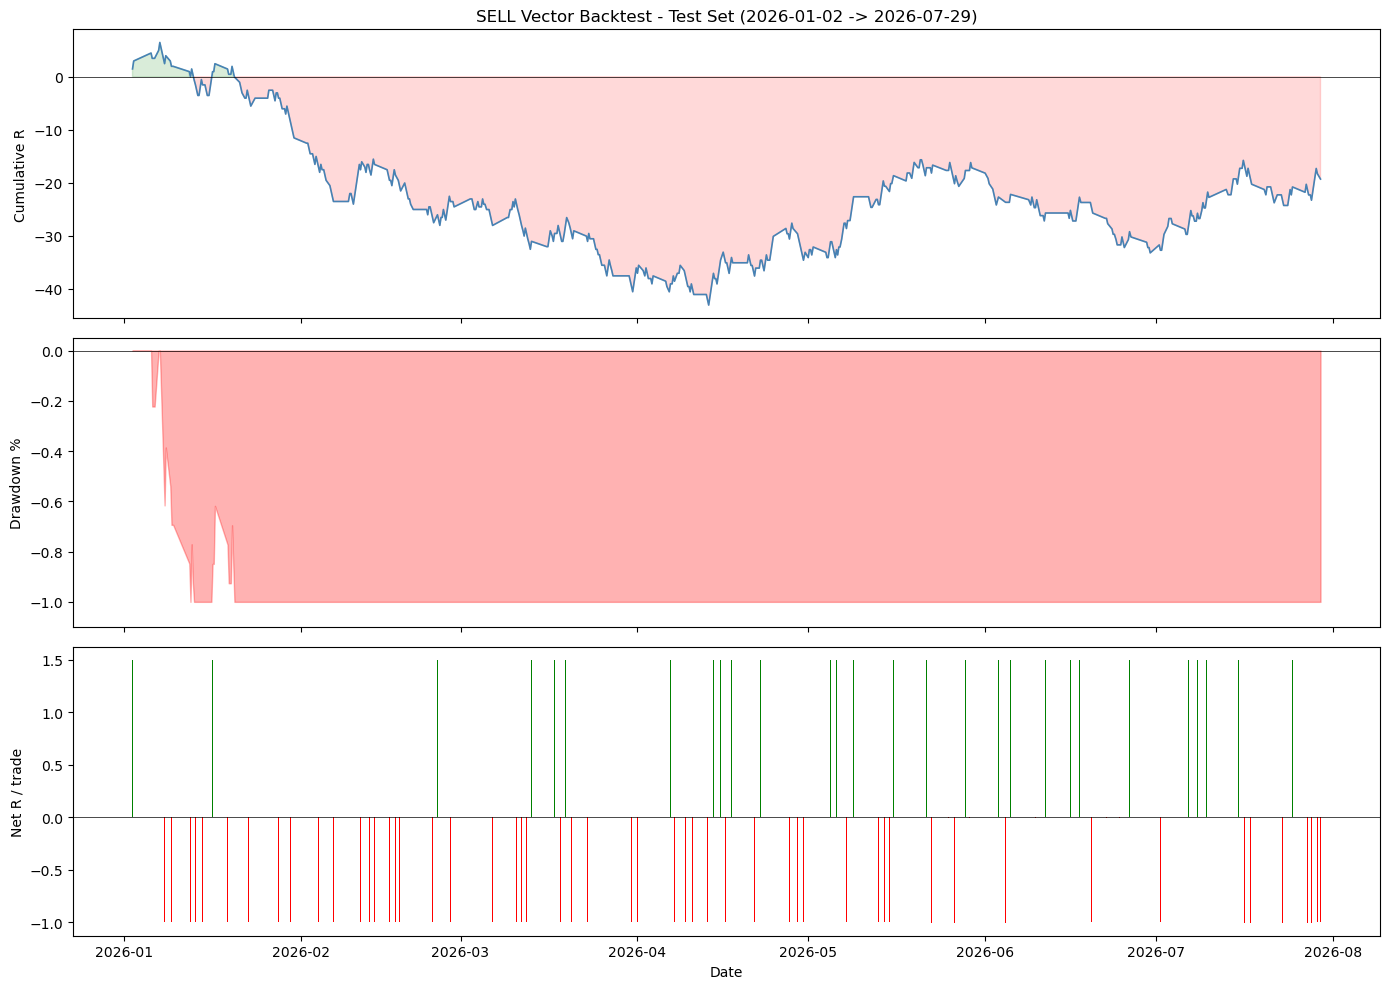


Max drawdown : -49.6R
Sharpe       : -0.03
Total trades : 556

=== Monthly breakdown ===
         trades  total_R  avg_R     wr
month                                 
2026-01      76  -11.531 -0.152  0.250
2026-02      83  -13.029 -0.157  0.265
2026-03      89  -11.534 -0.130  0.258
2026-04      86    2.956  0.034  0.349
2026-05      82   15.950  0.195  0.366
2026-06      61  -16.060 -0.263  0.197
2026-07      79   13.943  0.176  0.380


In [66]:
# Equity curve + drawdown charts
if trades is not None and len(trades) > 1:
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    ax = axes[0]
    ax.plot(trades["datetime"], trades["cumulative_R"], color="steelblue", lw=1.2)
    ax.fill_between(trades["datetime"], 0, trades["cumulative_R"],
                    where=trades["cumulative_R"] >= 0, color="green", alpha=0.15)
    ax.fill_between(trades["datetime"], 0, trades["cumulative_R"],
                    where=trades["cumulative_R"] < 0, color="red", alpha=0.15)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel("Cumulative R")
    t0 = trades["datetime"].min().strftime("%Y-%m-%d")
    t1 = trades["datetime"].max().strftime("%Y-%m-%d")
    ax.set_title(f"SELL Vector Backtest - Test Set ({t0} -> {t1})")

    ax = axes[1]
    ax.fill_between(trades["datetime"], 0, trades["drawdown_pct"], color="red", alpha=0.3)
    ax.set_ylabel("Drawdown %")
    ax.set_ylim(trades["drawdown_pct"].min() * 1.1, 0.05)
    ax.axhline(0, color="black", lw=0.5)

    ax = axes[2]
    colors = trades["net_R"].apply(lambda r: "green" if r > 0 else "red")
    ax.bar(trades["datetime"], trades["net_R"], color=colors, width=0.03)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel("Net R / trade")
    ax.set_xlabel("Date")

    plt.tight_layout()
    plt.show()

    print(f"\nMax drawdown : {bt_summary['max_dd_R']:+.1f}R")
    print(f"Sharpe       : {bt_summary['sharpe']}")
    print(f"Total trades : {bt_summary['n_trades']}")

    trades["month"] = trades["datetime"].dt.to_period("M").astype(str)
    monthly = trades.groupby("month").agg(
        trades=("net_R", "count"),
        total_R=("net_R", "sum"),
        avg_R=("net_R", "mean"),
        wr=("outcome", lambda x: round((x == "tp").sum() / max(len(x), 1), 3)),
    )
    print("\n=== Monthly breakdown ===")
    print(monthly.round(3).to_string())


## 12. Agent Confirmation Pipeline (Iteration 2)

Multi-agent validation layer. Every SELL signal is evaluated independently
by two AI agents. Only signals confirmed by both are promoted to actionable alerts.

- **Agent A (GPT-4o):** technical + macro context — trend, RSI, volatility, rate differentials
- **Agent B (Perplexity / web-search):** news, sentiment, event risk — data releases, headlines

Decision rule: both agents vote CONFIRM -> signal fires. One or both reject -> archived.

This section provides the prompt templates and a local evaluation stub.
Replace call_agent_stub() with real API calls once keys are configured.


In [67]:
# Agent evaluation pipeline (stub - replace with real API calls)

TECHNICAL_PROMPT = """You are a senior USDJPY H1 trader. Evaluate this sell signal.
Context:
- Date/time: {datetime} UTC
- Entry: {entry:.5f}
- ATR(14): {atr:.5f}
- D1 trend: {d1_trend} (1=uptrend, 0=downtrend)
- RSI(14): {rsi:.1f}
- Close vs EMA200: {vs_ema200:+.3f}
- ADX(14): {adx:.1f}
- Volume ratio: {vol_ratio:.2f}
- Model sell proba: {sell_proba:.3f}
- Buy model proba: {buy_proba:.3f}
Reply: DECISION: CONFIRM | REJECT
REASON: one sentence why"""

FUNDAMENTAL_PROMPT = """You are a macro FX analyst. Evaluate this USDJPY sell signal.
Date: {datetime} UTC | Entry: {entry:.5f}
Search for: BoJ/Fed divergence, DXY, key releases, risk sentiment.
Reply: DECISION: CONFIRM | REJECT
REASON: one sentence citing specific catalyst or lack thereof"""


def call_agent_stub(prompt_type, ctx):
    """Stub: replace with openai/perplexity API calls.
    Real implementation:
      - GPT-4o: openai.chat.completions.create(model="gpt-4o", messages=[...])
      - Perplexity: requests.post("https://api.perplexity.ai/chat/completions", ...)
    """
    if prompt_type == "technical":
        confirm = ctx.get("sell_proba", 0) > 0.35 and ctx.get("d1_trend", 1) == 0
        reason = "Downtrend + elevated sell probability" if confirm else "Weak signal or uptrend conflict"
    else:
        confirm = np.random.random() < 0.6
        reason = "Bearish macro catalyst cited" if confirm else "No clear catalyst found"
    return confirm, reason


agent_signals = sell_only_test[sell_only_test["sell_signal"] == 1].copy()

if len(agent_signals) == 0:
    print("Warning: No gated SELL signals to evaluate. Run Section 11 first.")
else:
    agent_signals = agent_signals.merge(
        df_features[["datetime", "d1_trend", "rsi_14", "close_vs_ema200", "adx_14", "volume_ratio"]],
        on="datetime", how="left"
    )
    agent_signals = agent_signals.merge(
        test_scores_with_labels[["datetime", "buy_proba"]], on="datetime", how="left"
    )

    results = []
    for _, row in agent_signals.iterrows():
        ctx = {
            "datetime": row["datetime"].strftime("%Y-%m-%d %H:%M"),
            "entry": row["close"],
            "atr": row["atr_14"],
            "d1_trend": int(row.get("d1_trend", -1)),
            "rsi": row.get("rsi_14", np.nan),
            "vs_ema200": row.get("close_vs_ema200", np.nan),
            "adx": row.get("adx_14", np.nan),
            "vol_ratio": row.get("volume_ratio", np.nan),
            "sell_proba": row["sell_proba"],
            "buy_proba": row.get("buy_proba", np.nan),
        }
        tc, tr = call_agent_stub("technical", ctx)
        fc, fr = call_agent_stub("fundamental", ctx)
        results.append({
            "datetime": row["datetime"], "entry": ctx["entry"],
            "sell_proba": ctx["sell_proba"],
            "agent_technical": "CONFIRM" if tc else "REJECT",
            "tech_reason": tr,
            "agent_fundamental": "CONFIRM" if fc else "REJECT",
            "fund_reason": fr,
            "both_confirm": tc and fc,
        })

    agent_df = pd.DataFrame(results)
    confirmed = agent_df[agent_df["both_confirm"]]
    rejected  = agent_df[~agent_df["both_confirm"]]

    print(f"\n=== Agent Confirmation Pipeline (stub) ===")
    print(f"Evaluated : {len(agent_df)}")
    print(f"Confirmed : {len(confirmed)}")
    print(f"Rejected  : {len(rejected)}")

    confirmed_wl = confirmed.merge(df_features[["datetime", "sell_label"]], on="datetime", how="left")
    rejected_wl  = rejected.merge(df_features[["datetime", "sell_label"]], on="datetime", how="left")
    kc, nc = int(confirmed_wl["sell_label"].sum()), len(confirmed_wl)
    kr, nr = int(rejected_wl["sell_label"].sum()), len(rejected_wl)
    pc = round(kc / nc, 3) if nc > 0 else float("nan")
    pr = round(kr / nr, 3) if nr > 0 else float("nan")
    lo, hi = wilson_ci(kc, nc)
    print(f"Agent-filtered precision : {pc:.3f}  CI95=[{lo:.3f}, {hi:.3f}]  n={nc}")
    print(f"Rejected precision       : {pr:.3f}  n={nr}")
    all_k = int(agent_signals["sell_label"].sum())
    print(f"Baseline (no agents)     : {all_k/len(agent_signals):.3f}  n={len(agent_signals)}")

    AGENT_DIR = ROOT / "data" / "signals"
    AGENT_DIR.mkdir(parents=True, exist_ok=True)
    agent_path = AGENT_DIR / f"{PAIR}_{TIMEFRAME}_agent_evaluation.csv"
    agent_df.to_csv(agent_path, index=False)
    print(f"\nAgent evaluation log saved -> {agent_path}")
    print("\n=== Sample agent decisions ===")
    display(agent_df.head(15))



=== Agent Confirmation Pipeline (stub) ===
Evaluated : 556
Confirmed : 10
Rejected  : 546
Agent-filtered precision : 0.600  CI95=[0.313, 0.832]  n=10
Rejected precision       : 0.293  n=546
Baseline (no agents)     : 0.299  n=556

Agent evaluation log saved -> C:\Users\david\OneDrive\Documents\fx-prival\ml-signal-service\data\signals\USDJPY_H1_agent_evaluation.csv

=== Sample agent decisions ===


,datetime,entry,sell_proba,agent_technical,tech_reason,agent_fundamental,fund_reason,both_confirm
0,2026-01-02 11:00:00,156.906,0.284089,REJECT,Weak signal or uptrend conflict,CONFIRM,Bearish macro catalyst cited,False
1,2026-01-02 16:00:00,156.844,0.328336,REJECT,Weak signal or uptrend conflict,CONFIRM,Bearish macro catalyst cited,False
2,2026-01-05 17:00:00,156.571,0.285520,REJECT,Weak signal or uptrend conflict,REJECT,No clear catalyst found,False
3,2026-01-05 22:00:00,156.330,0.319075,REJECT,Weak signal or uptrend conflict,CONFIRM,Bearish macro catalyst cited,False
4,2026-01-06 03:00:00,156.445,0.296446,REJECT,Weak signal or uptrend conflict,CONFIRM,Bearish macro catalyst cited,False
5,2026-01-06 08:00:00,156.361,0.299338,REJECT,Weak signal or uptrend conflict,REJECT,No clear catalyst found,False
6,2026-01-07 01:00:00,156.657,0.287812,REJECT,Weak signal or uptrend conflict,REJECT,No clear catalyst found,False
7,2026-01-07 06:00:00,156.531,0.312190,REJECT,Weak signal or uptrend conflict,CONFIRM,Bearish macro catalyst cited,False
8,2026-01-07 11:00:00,156.456,0.392261,REJECT,Weak signal or uptrend conflict,REJECT,No clear catalyst found,False
9,2026-01-07 16:00:00,156.401,0.388133,REJECT,Weak signal or uptrend conflict,CONFIRM,Bearish macro catalyst cited,False
